# Sentiment Analysis
## Objective


Agricultural competitiveness is not driven solely by quantitative production indicators. Public perception, producer confidence, pricing pressure, sustainability concerns, agricultural policy discussions, and consumer attitudes also influence the long-term stability and competitiveness of the dairy sector. Therefore, this section extends the analytical framework by incorporating sentiment analysis using dairy-related public discussions collected from Reddit.

# Import Libraries & Load Data

In [124]:
import pandas as pd
import numpy as np
import datetime as dt

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing
import re
import unicodedata
import nltk

from nltk.sentiment import SentimentIntensityAnalyzer

# Reddit API
import praw

# MongoDB
from pymongo import MongoClient

# Environment variable management
from dotenv import load_dotenv
from os import getenv

# Statistical testing
from scipy.stats import ttest_ind

# Display settings
pd.set_option("display.max_columns", None)

# Plot styling
sns.set_theme(style="whitegrid",context="notebook",palette="colorblind")

# Download required NLP resources
nltk.download("vader_lexicon")

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ializ\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Reddit API and MongoDB Configuration

In [2]:
# Load environment variables
load_dotenv()

# Validate environment variables
required_env_vars = ["APP_ID", "APP_SECRET", "REDDIT_USERNAME", "MONGO_URI"]

missing_vars = [
    var for var in required_env_vars
    if getenv(var) is None
]

if missing_vars:
    raise ValueError(f"Missing environment variables: {missing_vars}")

print("All required environment variables loaded successfully.")

All required environment variables loaded successfully.


In [3]:
# Configure Reddit API connection
reddit = praw.Reddit(
    client_id=getenv("APP_ID"),
    client_secret=getenv("APP_SECRET"),
    user_agent=f"pda-2025 u/{getenv('REDDIT_USERNAME')}"
)

print("Reddit API connection established.")

Reddit API connection established.


In [4]:
# Configure MongoDB connection
mongo_client = MongoClient(getenv("MONGO_URI"))

# Verify MongoDB server connection
mongo_client.admin.command("ping")

# Create database and collection
sentiment_db = mongo_client["dairy_sentiment_db"]
sentiment_collection = sentiment_db["reddit_sentiment"]

print("MongoDB connection established and verified.")

MongoDB connection established and verified.


# Dataset Collection Strategy
For countries selection, the same ones which were taken for forecasting are taken. In subreddit selection each country is linked to one or more country-specific or agriculture-related subreddits based on: discussion activity and geographic relevance.

In final notebook, a multilingual keyword collection strategy is implemented because after trying multiple times in only english langauage, the relevant results were not being pulled because agricultural discussions of other countries were mostly discussed in native languages. Therefore, with google translate the following section of the code was developed in multi langauages.

The keyword lists include both:
- producer-oriented terminology (e.g., milk production, subsidies, agricultural protests),
- and consumer-oriented terminology (e.g., butter prices, cheese prices, dairy products).

This separation supports later comparative sentiment analysis between producer and consumer.

In [87]:
# Countries used across forecasting and sentiment analysis

countries = {
    "Ireland": {
        "subreddits": ["ireland", "AskIreland"],
        "keywords": [
            "dairy farming", "milk prices", "dairy farmers",
            "farmer protests", "agricultural subsidies",
            "milk production", "beef and dairy", "Teagasc"
        ]
    },
    "France": {
        "subreddits": ["france", "agriculture"],
        "keywords": [
            "lait", "prix du lait", "producteurs laitiers",
            "élevage laitier", "agriculteurs", "PAC",
            "FNSEA", "Lactalis", "fromage", "beurre"
        ]
    },
    "Germany": {
        "subreddits": ["germany", "de", "Landwirtschaft"],
        "keywords": [
            "Milch", "Milchpreis", "Milchbauern",
            "Milchproduktion", "Landwirtschaft",
            "Bauernproteste", "Agrarpolitik",
            "Subventionen", "Butterpreise", "Käsepreise"
        ]
    },
    "Italy": {
        "subreddits": ["italy"],
        "keywords": [
            "latte", "prezzo del latte", "allevamento",
            "allevatori", "produzione latte",
            "Coldiretti", "Parmigiano", "formaggio",
            "burro", "sussidi agricoli"
        ]
    },
    "Netherlands": {
        "subreddits": ["Netherlands", "thenetherlands"],
        "keywords": [
            "melk", "melkprijs", "melkveehouderij",
            "zuivel", "boerenprotest", "stikstof",
            "landbouw", "FrieslandCampina",
            "kaas", "boter"
        ]
    },
    "Poland": {
        "subreddits": ["poland", "Polska"],
        "keywords": [
            "mleko", "ceny mleka", "rolnicy",
            "hodowla bydła", "produkcja mleka",
            "dopłaty", "rolnictwo", "masło",
            "ser", "protest rolników"
        ]
    }
}

Moreover, for producer and consumer perspective classification, keywords are grouped into two sepaarte analytical categories. This keyword grouping strategy provides a lightweight rule-based approach for identifying the likely perspective associated with each Reddit discussion. The approach was selected because:
- the dataset is multilingual,
- labelled training data is unavailable,
- and manual classification of all posts would not be scalable.

It is acknowledged that keyword-based categorisation may introduce some ambiguity, however, it provides an interpretable and reproducible framework suitable for exploratory sentiment analysis.

In [88]:
keyword_groups = {
    "producer": [
        # English / Ireland
        "dairy farming", "milk prices", "dairy farmers",
        "farmer protests", "agricultural subsidies",
        "milk production", "beef and dairy", "Teagasc",

        # French
        "prix du lait", "producteurs laitiers",
        "élevage laitier", "agriculteurs", "PAC",
        "FNSEA", "Lactalis",

        # German
        "Milchpreis", "Milchbauern", "Milchproduktion",
        "Landwirtschaft", "Bauernproteste",
        "Agrarpolitik", "Subventionen",

        # Italian
        "prezzo del latte", "allevamento",
        "allevatori", "produzione latte",
        "Coldiretti", "sussidi agricoli",

        # Dutch
        "melkprijs", "melkveehouderij",
        "boerenprotest", "stikstof",
        "landbouw", "FrieslandCampina",

        # Polish
        "ceny mleka", "rolnicy", "hodowla bydła",
        "produkcja mleka", "dopłaty",
        "rolnictwo", "protest rolników"
    ],

    "consumer": [
        # English
        "dairy products", "food prices",
        "butter prices", "cheese prices",

        # French
        "lait", "fromage", "beurre",

        # German
        "Milch", "Butterpreise", "Käsepreise",

        # Italian
        "latte", "Parmigiano", "formaggio", "burro",

        # Dutch
        "melk", "zuivel", "kaas", "boter",

        # Polish
        "mleko", "masło", "ser"
    ]
}

# Reddit Data Collection Pipeline

A reusable Reddit collection function is developed to automate the extraction of dairy-related discussions from multiple country-specific subreddits. Each collected Reddit post is stored together with metadata including country, subreddit, keyword, perspective, publication date, title, post text, engagement metrics, and URL.


In [7]:
# Function to collect Reddit posts from multiple countries and subreddits
def collect_reddit_posts(
    reddit_client,
    countries_config,
    keyword_groups=None,
    limit_per_query=25
):

    # Store all collected Reddit posts
    collected_posts = []

    # Loop through each country configuration
    for country, config in countries_config.items():

        # Loop through selected subreddits for that country
        for subreddit_name in config["subreddits"]:

            subreddit = reddit_client.subreddit(subreddit_name)

            # Loop through multilingual dairy/agriculture keywords
            for keyword in config["keywords"]:

                search_query = keyword

                # Default perspective label
                perspective = "Other"

                # Match keyword to producer or consumer 
                if keyword_groups is not None:
                    for group_name, group_terms in keyword_groups.items():
                        if keyword in group_terms:
                            perspective = group_name
                            break

                try:
                    # Search Reddit posts using keyword query
                    for post in subreddit.search(
                        search_query,
                        sort="relevance",
                        limit=limit_per_query
                    ):

                        # Combine title and body text
                        full_text = f"{post.title} {post.selftext}"

                        # Store relevant metadata
                        collected_posts.append({
                            "source": "Reddit",
                            "country": country,
                            "subreddit": subreddit_name,
                            "perspective": perspective,
                            "keyword": keyword,
                            "search_query": search_query,
                            "date": dt.datetime.fromtimestamp(post.created_utc),
                            "title": post.title,
                            "raw_text": post.selftext,
                            "full_text": full_text,
                            "score": post.score,
                            "num_comments": post.num_comments,
                            "url": post.url,
                            "permalink": "https://www.reddit.com" + post.permalink
                        })

                # Skip failed searches without stopping execution
                except Exception as error:
                    print(
                        f"Skipped query: {search_query} "
                        f"in r/{subreddit_name}. Error: {error}"
                    )

    return pd.DataFrame(collected_posts)

In [8]:
# Collect Reddit posts into a raw dataset
sentiment_raw_df = collect_reddit_posts(
    reddit_client=reddit,
    countries_config=countries,
    keyword_groups=keyword_groups,
    limit_per_query=25
)

sentiment_raw_df.shape

(1384, 14)

In [9]:
sentiment_raw_df.head()

,source,country,subreddit,perspective,keyword,search_query,date,title,raw_text,full_text,score,num_comments,url,permalink
0,Reddit,Ireland,ireland,producer,dairy farming,dairy farming,2025-03-18 14:44:42,"From milking 1,000 cows to producing power for...",,"From milking 1,000 cows to producing power for...",183,71,https://m.independent.ie/farming/from-milking-...,https://www.reddit.com/r/ireland/comments/1je6...
1,Reddit,Ireland,ireland,producer,dairy farming,dairy farming,2019-03-06 13:23:50,Veganism a passing fad and 'will only last two...,,Veganism a passing fad and 'will only last two...,89,173,https://www.independent.ie/business/farming/da...,https://www.reddit.com/r/ireland/comments/axyr...
2,Reddit,Ireland,ireland,producer,dairy farming,dairy farming,2025-05-07 07:40:43,Wexford farmer seeks permission to change beef...,,Wexford farmer seeks permission to change beef...,0,20,https://m.independent.ie/regionals/wexford/enn...,https://www.reddit.com/r/ireland/comments/1kgq...
3,Reddit,Ireland,ireland,producer,dairy farming,dairy farming,2022-07-16 09:45:25,Popular among the farming community,,Popular among the farming community,1747,453,https://i.redd.it/skixr9828wb91.png,https://www.reddit.com/r/ireland/comments/w0c2...
4,Reddit,Ireland,ireland,producer,dairy farming,dairy farming,2022-06-28 01:38:42,"So, this is what counts as dairy farming in th...",,"So, this is what counts as dairy farming in th...",41,42,https://v.redd.it/fspi0fkvl8891,https://www.reddit.com/r/ireland/comments/vma0...


In [10]:
sentiment_raw_df["perspective"].value_counts()

perspective
producer    860
consumer    524
Name: count, dtype: int64

# Dataset Quality Filtering
The collected dataset is not found to be clean which is expected from social media sources. Therefore, filtering will be performed.

Lets first drop the duplicate posts which will be identified using the unique post permalink.

In [94]:
sentiment_raw_df = sentiment_raw_df.drop_duplicates(subset=["permalink"]).copy()
sentiment_raw_df.shape

(1299, 16)

A unified representation of each Reddit discussion for downstream preprocessing and sentiment modelling will be created by combining post titles and body text.

In [95]:
sentiment_raw_df["combined_text"] = (
    sentiment_raw_df["title"].fillna("") + " " +
    sentiment_raw_df["raw_text"].fillna("")
)

Because keyword-based Reddit collection can retrieve loosely related or irrelevant posts, an additional rule-based relevance filtering stage is introduced wich is kept with two multilingual keyword groups. A reddit post will be retained if it contains keywords mentioned in either of these keyword groups.

In [99]:
dairy_terms = [
    "dairy", "milk", "butter", "cheese",
    "lait", "beurre", "fromage",
    "milch", "käse",
    "latte", "burro", "formaggio", "parmigiano",
    "melk", "zuivel", "kaas", "boter",
    "mleko", "masło", "ser"
]

sector_terms = [
    "farm", "farmer", "farming", "agriculture", "agricultural",
    "production", "prices", "price", "subsidies", "protest",
    "exports", "cattle", "livestock",

    "agriculteur", "agriculteurs", "élevage",
    "prix", "production", "subventions", "manifestation",

    "bauer", "bauern", "landwirtschaft", "produktion",
    "preis", "preise", "subventionen", "protest",

    "allevamento", "allevatori", "agricoltura",
    "produzione", "prezzo", "prezzi", "sussidi",

    "boer", "boeren", "landbouw", "veehouderij",
    "prijs", "prijzen", "stikstof", "protest",

    "rolnik", "rolnicy", "rolnictwo", "hodowla",
    "produkcja", "ceny", "dopłaty", "protest"
]

# Function to identify dairy-sector relevant Reddit posts
def is_relevant_dairy_sector_post(text):

    # Convert text to lowercase for matching
    text = str(text).lower()

    # Check whether dairy-related terms exist
    has_dairy_term = any(term.lower() in text for term in dairy_terms)

    # Check whether agriculture-sector terms exist
    has_sector_term = any(term.lower() in text for term in sector_terms)

    # Retain posts containing both dairy and sector-related terms
    return has_dairy_term and has_sector_term

In [102]:
# Apply relevance filtering
sentiment_raw_df["is_relevant"] = sentiment_raw_df["combined_text"].apply(is_relevant_dairy_sector_post)
sentiment_df = sentiment_raw_df[sentiment_raw_df["is_relevant"]].copy()
sentiment_df.shape

(270, 16)

# Dataset Exploration

After preprocessing, lets explore collected data. Its important because social media data can become biased toward specific countries, communities, or time periods.

In [103]:
# Country distribution
country_distribution = sentiment_df["country"].value_counts().reset_index()
country_distribution.columns = ["country", "post_count"]
country_distribution

,country,post_count
0,Ireland,89
1,Germany,50
2,Italy,50
3,France,44
4,Netherlands,24
5,Poland,13


In [109]:
# Perspective distribution
perspective_distribution = sentiment_df["perspective"].value_counts().reset_index()
perspective_distribution.columns = ["perspective", "post_count"]
perspective_distribution

,perspective,post_count
0,producer,201
1,consumer,58


The dataset contains a substantially larger number of producer-related posts than consumer-related posts. This imbalance is analytically reasonable because consumer discussions are naturally more limited because they are typically restricted to:food prices,dairy products or supermarket-related discussions. This imbalance will be acknowledged as a limitation when interpreting results.

In [18]:
# Subreddit distribution
subreddit_distribution = sentiment_df["subreddit"].value_counts().reset_index()
subreddit_distribution.columns = ["subreddit", "post_count"]
subreddit_distribution.head(15)

,subreddit,post_count
0,ireland,71
1,italy,50
2,france,42
3,de,38
4,AskIreland,18
5,thenetherlands,17
6,Polska,13
7,Landwirtschaft,10
8,Netherlands,7
9,agriculture,2


In [106]:
# Year distribution
sentiment_df["year"] = pd.to_datetime(sentiment_df["date"]).dt.year # Extract publication year from Reddit post date
year_distribution = sentiment_df["year"].value_counts().sort_index().reset_index()
year_distribution.columns = ["year", "post_count"]
year_distribution

,year,post_count
0,2016,9
1,2017,12
2,2018,14
3,2019,14
4,2020,21
5,2021,14
6,2022,32
7,2023,33
8,2024,34
9,2025,47


Very early years contained extremely small numbers of posts and therefore provide unreliable sentiment estimates. Therefore, only years with meaningful discussion volume are retained for downstream analysis.


In [107]:
# Keep only modern discussion years
sentiment_df = sentiment_df[sentiment_df["year"] >= 2016].reset_index(drop=True)
sentiment_df.shape

(259, 17)

In [108]:
sentiment_df.year.sort_values().unique()

array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
      dtype=int32)

## Manual Relevance Validation

In this section, a manual relevance validation step is performed to assess the overall quality of the filtered dataset by taking a fixed random seed (random_state=42) to ensure the results remain consistent across executions. This manual validation step is not used to train the model, it only serves as a quality assessment mechanism to evaluate the effectiveness of our previous strategies.

In [22]:
validation_sample = sentiment_df[[
    "country",
    "perspective",
    "subreddit",
    "keyword",
    "title",
    "combined_text"
]].sample(30, random_state=42).reset_index()

validation_sample

,index,country,perspective,subreddit,keyword,title,combined_text
0,66,Ireland,producer,AskIreland,dairy farming,Dating in Ireland?,"Dating in Ireland? How's it going, is it just ..."
1,45,Ireland,producer,ireland,dairy farmers,Bó - a short documentary about a day as a dair...,Bó - a short documentary about a day as a dair...
2,9,Ireland,producer,ireland,dairy farming,Focusing of cost and not the ability to pass i...,Focusing of cost and not the ability to pass i...
3,73,Ireland,producer,AskIreland,milk prices,Is this grocery list confusing?,Is this grocery list confusing? As part of tea...
4,137,Germany,producer,de,Milchpreis,Höherer Milchpreis: Bauer erhält nur einen Cen...,Höherer Milchpreis: Bauer erhält nur einen Cen...
5,104,France,producer,france,élevage laitier,"""J'ai vu des veaux tués à coups de marteau par...","""J'ai vu des veaux tués à coups de marteau par..."
6,206,Italy,producer,italy,allevatori,"Allevatori di ratti, venite a me. ( feeders, n...","Allevatori di ratti, venite a me. ( feeders, n..."
7,229,Netherlands,consumer,thenetherlands,melk,Het is weer het seizoen: Wat voegen jullie toe...,Het is weer het seizoen: Wat voegen jullie toe...
8,125,France,producer,agriculture,agriculteurs,Mushrooms: We are growing more but eating less...,Mushrooms: We are growing more but eating less...
9,212,Italy,producer,italy,produzione latte,"La ""dieta planetaria"" degli esperti di The Lan...","La ""dieta planetaria"" degli esperti di The Lan..."


In [23]:
# validation_sample.loc[28,"combined_text"]

In [110]:
validation_labels = {
    66: "Irrelevant",
    45: "Relevant",
    9: "Relevant",
    73: "Partial",
    137: "Relevant",
    104: "Irrelevant",
    206: "Irrelevant",
    229: "Irrelevant",
    125: "Irrelevant",
    212: "Irrelevant",
    84: "Relevant",
    33: "Relevant",
    250: "Irrelevant",
    68: "Irrelevant",
    46: "Relevant",
    108: "Relevant",
    6: "Relevant",
    30: "Partial",
    101: "Irrelevant",
    55: "Irrelevant",
    24: "Relevant",
    178: "Irrelevant",
    205: "Irrelevant",
    180: "Relevant",
    168: "Irrelevant",
    15: "Relevant",
    132: "Relevant",
    227: "Irrelevant",
    237: "Irrelevant",
    143: "Relevant"
}

validation_sample["relevance"] = validation_sample["index"].map(validation_labels)

validation_sample[["index", "title", "relevance"]].head()

,index,title,relevance
0,66,Dating in Ireland?,Irrelevant
1,45,Bó - a short documentary about a day as a dair...,Relevant
2,9,Focusing of cost and not the ability to pass i...,Relevant
3,73,Is this grocery list confusing?,Partial
4,137,Höherer Milchpreis: Bauer erhält nur einen Cen...,Relevant


The dataset still contains some noisy or ambiguous Reddit discussions. However, the filtering strategy substantially improves relevance compared to the initial collection.

In [25]:
validation_sample["relevance"].value_counts().reset_index()

,relevance,count
0,Irrelevant,15
1,Relevant,13
2,Partial,2


In [111]:
# Lets see overall percentage of relevant/partial relevant posts from the sample
round((validation_sample["relevance"].isin(["Relevant", "Partial"]).mean()) * 100,2)

np.float64(50.0)

Despite the remaining noise, the dataset is considered sufficiently meaningful for exploratory sentiment analysis.

# Text Preprocessing and Cleaning

Reddit discussions contain noisy and inconsistent text including URLs, punctuation, emojis, numbers, formatting symbols, and multilingual writing styles. Therefore, a lightweight preprocessing strategy is applied before sentiment analysis. The preprocessing approach is intentionally conservative because the dataset is multilingual. Aggressive preprocessing techniques such as stemming, lemmatization, or English-only stopword removal could distort non-English vocabulary and reduce interpretability.

In [112]:
def preprocess_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Normalize multilingual text
    text = unicodedata.normalize("NFKC", text)

    # Keep letters from all languages; remove punctuation/symbols
    text = re.sub(r"[^\w\s']", " ", text, flags=re.UNICODE)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove underscores
    text = text.replace("_", " ")

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [114]:
# Apply preprocessing function to combined Reddit text
sentiment_df["clean_text"] = sentiment_df["combined_text"].apply(preprocess_text)
# Remove rows where cleaned text becomes empty after preprocessing
sentiment_df = sentiment_df[sentiment_df["clean_text"].str.strip() != ""].reset_index(drop=True)
sentiment_df.shape

(259, 18)

# Sentiment Analysis using VADER

The VADER sentiment model is used because it is specifically designed for short, informal, social-media-style text. Since Reddit discussions frequently contain conversational language, emotional expressions, and opinion-based statements, VADER provides a suitable baseline sentiment approach for this study.

For each Reddit post, the VADER compound polarity score is calculated using the cleaned text. The compound score ranges from -1 (most negative) to +1 (most positive).

The standard VADER sentiment thresholds are applied:

score ≥ 0.05 → Positive
score ≤ -0.05 → Negative
otherwise → Neutral

Although the dataset contains multilingual content, VADER is still used as an interpretable baseline sentiment model because it was covered within our ML module and remains effective for identifying overall polarity patterns in mixed social-media discussions. This limitation will also be acknowledged.

In [119]:
# Calculate VADER compound sentiment score for each Reddit post
sentiment_df["sentiment_score"] = sentiment_df["clean_text"].apply(lambda text: sia.polarity_scores(str(text))["compound"])

In [121]:
# Function to classify sentiment based on VADER thresholds
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Create categorical sentiment labels from sentiment score
sentiment_df["sentiment_label"] = sentiment_df["sentiment_score"].apply(classify_sentiment)

In [123]:
# Overall sentiment distribution
sentiment_distribution = sentiment_df["sentiment_label"].value_counts().reset_index()
sentiment_distribution.columns = ["sentiment", "post_count"]
sentiment_distribution

,sentiment,post_count
0,Negative,99
1,Positive,87
2,Neutral,73


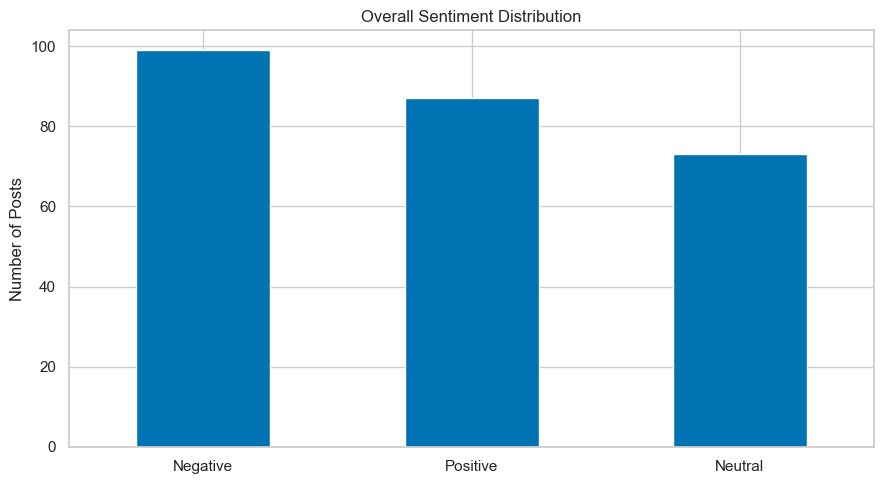

In [125]:
# Visualise overall sentiment distribution
sentiment_distribution.plot(
    kind="bar",
    x="sentiment",
    y="post_count",
    figsize=(9, 5)
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()

In [126]:
# Sentiment label percentages
sentiment_percentages = (
    sentiment_df["sentiment_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

sentiment_percentages.columns = ["sentiment", "percentage"]

sentiment_percentages

,sentiment,percentage
0,Negative,38.22
1,Positive,33.59
2,Neutral,28.19


### Observation

The overall sentiment distribution shows that negative sentiment is the largest category, followed by positive and neutral sentiment. This suggests that dairy and agricultural discussions on Reddit contain a slightly stronger negative tone overall.

This is reasonable because many agricultural discussions involve issues such as milk prices, production pressure, subsidies, inflation, farmer protests, and policy concerns.

Neutral posts likely represent informational or factual discussions rather than strongly emotional opinions.

# TF-IDF Feature Extraction

Now, TF-IDF (Term Frequency–Inverse Document Frequency) is used to identify the most important discussion terms within our dataset. Unlike simple word frequency counting, TF-IDF reduces the importance of extremely common terms while highlighting words that are more distinctive across the corpus. This will help identify the dominant agricultural and dairy-related themes discussed by Reddit users.

And again, since the data contains multilingual content, a custom multilingual stopword list will be created to reduce common filler words.

In [141]:
multilingual_stopwords = [
    # English
    "the", "and", "to", "of", "in", "is", "it", "for", "on", "with",
    "as", "this", "that", "are", "was", "be", "by", "from", "at",
    "or", "an", "a", "have", "has", "had", "they", "them", "their",
    "you", "your", "we", "our", "but", "not", "just", "about", "over",
    "like", "can", "would", "could", "should",

    # French
    "le", "la", "les", "de", "des", "du", "un", "une", "et", "en",
    "dans", "pour", "que", "qui", "sur", "au", "aux", "est", "ce",
    "se", "pas", "plus", "avec", "mais", "son", "ses", "tout",

    # German
    "der", "die", "das", "den", "dem", "und", "zu", "mit", "auf",
    "ein", "eine", "von", "für", "im", "ist", "ich", "nicht", "als",

    # Italian
    "il", "lo", "gli", "di", "del", "della", "e", "che", "per",
    "con", "è", "una", "sono", "dei", "nel", "come", "più",

    # Dutch
    "het", "een", "van", "op", "te", "voor", "met", "dat", "zijn",
    "niet", "maar", "als", "over",

    # Polish
    "i", "w", "na", "z", "do", "że", "to", "jest", "nie", "się",
    "dla", "od", "po", "o",

    # Extra short/noisy multilingual terms observed in output
    "all", "da", "so", "ma", "me", "si", "mi", "ne", "ai", "qu",
    "par", "ci"
]

As the first run might not be give the best results alone so we will first create a reusable function so code is not repeated.

In [142]:
def run_tfidf(text_data, stopword_list, max_features=30):
    tfidf = TfidfVectorizer(
        max_features=max_features,
        stop_words=stopword_list,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.7,
        token_pattern=r"(?u)\b[a-zA-ZÀ-ÿ]{4,}\b"
    )

    tfidf_matrix = tfidf.fit_transform(text_data)

    tfidf_terms = pd.DataFrame({
        "term": tfidf.get_feature_names_out(),
        "score": tfidf_matrix.mean(axis=0).A1
    }).sort_values(
        by="score",
        ascending=False
    )

    return tfidf_terms, tfidf_matrix

In [143]:
multilingual_stopwords = list(set(multilingual_stopwords))

tfidf_terms_initial, tfidf_matrix_initial = run_tfidf(
    sentiment_df["clean_text"],
    multilingual_stopwords
)

tfidf_terms_initial

,term,score
5,dairy,0.125776
15,milk,0.107187
13,ireland,0.061960
3,auch,0.057111
29,will,0.054217
25,there,0.054055
21,prix,0.046132
24,sont,0.044549
14,latte,0.043802
17,more,0.042512


As seen the output still contains several conversational multilingual terms that are not directly related to dairy or agricultural discussions.

Therefore, additional noisy terms identified will be added to the stopword list.

In [144]:
# Adding extra noisy terms
extra_noise_words = [
    "all", "da", "so", "ma", "me", "si", "mi", "ne", "ai", "qu",
    "par", "ci", "will", "there", "people", "vous", "anche",
    "alla", "questo", "essere", "delle", "solo", "meme", "faire",
    "tutto", "très", "molto", "degli", "beaucoup", "acqua", "sonn"
]

refined_stopwords = list(set(multilingual_stopwords + extra_noise_words))

In [149]:
tfidf_terms, tfidf_matrix = run_tfidf(
    sentiment_df["clean_text"],
    refined_stopwords
)

tfidf_terms

,term,score
7,dairy,0.109199
19,milk,0.108890
12,farmers,0.072450
14,ireland,0.062356
18,milch,0.060145
29,what,0.052694
8,dell,0.048436
16,latte,0.048088
1,also,0.047521
2,auch,0.046616


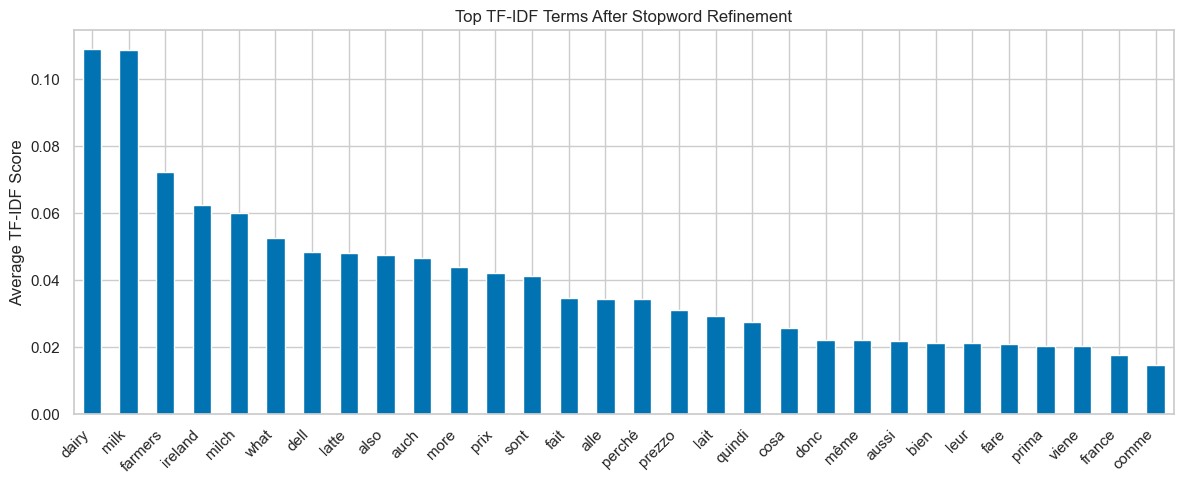

In [146]:
tfidf_terms.plot(kind="bar",x="term",y="score",figsize=(12, 5))

plt.title("Top TF-IDF Terms After Stopword Refinement")
plt.xlabel("")
plt.ylabel("Average TF-IDF Score")
plt.xticks(rotation=45, ha="right")
plt.legend().remove()
plt.tight_layout()

TF-IDF analysis highlights the dominant discussion topics across multilingual Reddit posts. Terms such as “dairy”, “milk”, “farmers”, and country-specific dairy vocabulary indicate that the dataset successfully captures agricultural and dairy-related discourse. Some conversational words remain due to the informal and multilingual nature of Reddit discussions. However, complete removal of all multilingual conversational terms was not attempted because overly aggressive stopword filtering could also remove contextually meaningful agricultural discussion terms. 

# Comparative Sentiment Analysis

Lets now examine how sentiment differs across countries, stakeholder perspectives, and time periods.

In [150]:
# Sentiment distribution across countries
country_sentiment = pd.crosstab(
    sentiment_df["country"],
    sentiment_df["sentiment_label"]
)

country_sentiment

sentiment_label,Negative,Neutral,Positive
country,,,
France,19,12,13
Germany,29,18,2
Ireland,21,18,43
Italy,8,15,25
Netherlands,10,9,4
Poland,12,1,0


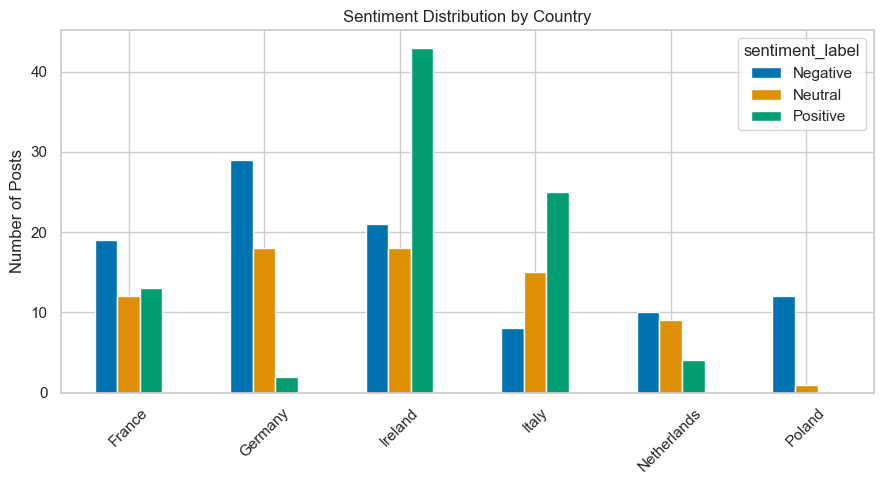

In [163]:
country_sentiment.plot(kind="bar",figsize=(9, 5))

plt.title("Sentiment Distribution by Country")
plt.xlabel("")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()

### Observation

As seen, country-level sentiment patterns vary considerably across the dataset. Ireland and Italy show the strongest positive sentiment presence, suggesting relatively optimistic discussion around dairy production and agricultural activity. In contrast, Germany and Poland display substantially stronger negative sentiment patterns, indicating more concern-driven discussions linked to agricultural pressure, policy challenges, or economic difficulties. France appears relatively balanced across sentiment categories, while the Netherlands shows a moderately negative distribution.

These differences suggest that dairy-sector discussions are influenced by country-specific agricultural conditions, regulatory environments, and economic pressures.

In [164]:
# Sentiment distribution by perspective
perspective_sentiment = pd.crosstab(
    sentiment_df["perspective"],
    sentiment_df["sentiment_label"]
)

perspective_sentiment

sentiment_label,Negative,Neutral,Positive
perspective,,,
consumer,20,22,16
producer,79,51,71


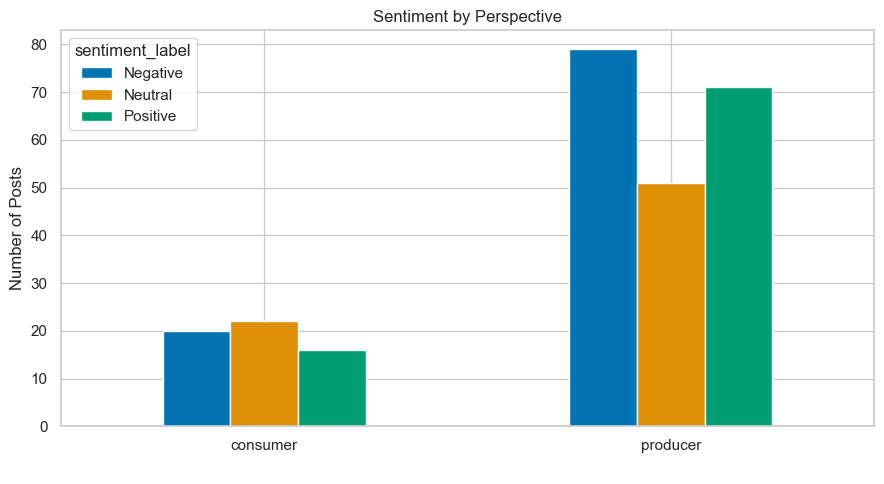

In [158]:
perspective_sentiment.plot(kind="bar",figsize=(9, 5))

plt.title("Sentiment by Perspective")
plt.xlabel(" ")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.tight_layout()

### Observation

The overall sentiment distribution shows that negative posts in both consumer and producer slightly outnumber positive posts across the dataset. This suggests that online dairy and agricultural discussions on Reddit are frequently associated with economic pressure, production concerns, subsidies, protests, inflation, and policy-related uncertainty. However, the presence of a substantial number of positive posts indicates that discussions are not entirely pessimistic and also include supportive or optimistic views regarding dairy production, agricultural identity, and market performance. Neutral posts represent informational or discussion-based content where strong emotional polarity is not clearly expressed.


In [165]:
# Sentiment distribution over time
year_sentiment = pd.crosstab(
    sentiment_df["year"],
    sentiment_df["sentiment_label"]
)

year_sentiment

sentiment_label,Negative,Neutral,Positive
year,,,
2016,2,5,2
2017,2,6,4
2018,7,4,3
2019,5,5,4
2020,7,7,7
2021,9,1,4
2022,14,7,11
2023,9,11,13
2024,13,8,13


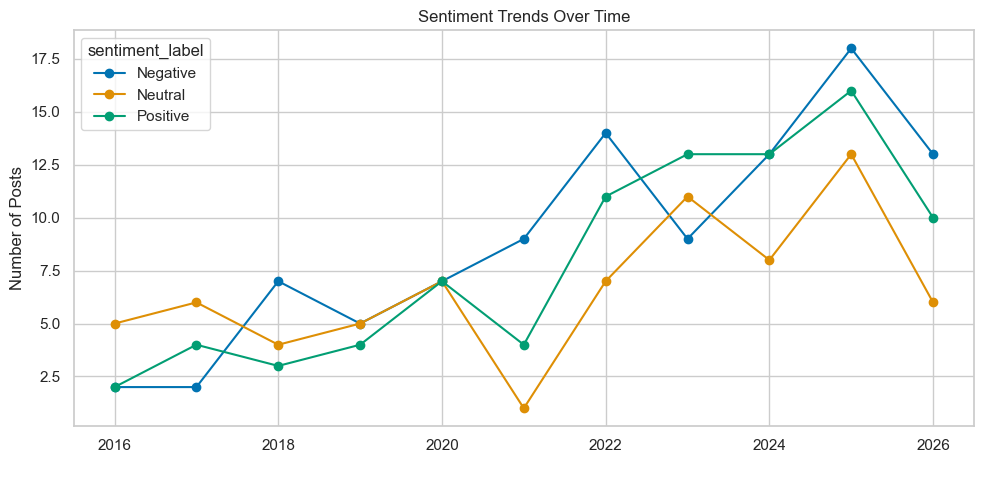

In [161]:
year_sentiment.plot(kind="line",figsize=(10, 5),marker="o")

plt.title("Sentiment Trends Over Time")
plt.xlabel(" ")
plt.ylabel("Number of Posts")
plt.tight_layout()

### Observation

Sentiment activity increases noticeably after 2020, indicating growing online discussion around dairy and agricultural issues in recent years.
Negative sentiment rises strongly between 2021 and 2025, wile positive sentiment also increases over time, particularly after 2022, suggesting that discussions became more active overall rather than purely negative. This indicates a more polarized but highly engaged discussion environment surrounding the dairy sector. Neutral sentiment remains comparatively stable across years, representing ongoing informational or non-emotional discussion.

# Study Limitations

Several limitations should be considered when interpreting the sentiment analysis results:

- The dataset was collected exclusively from Reddit, meaning the findings reflect online discussion communities rather than the full population.
- Post volumes differ across countries and years, creating potential imbalance in representation.
- The dataset contains multilingual content, while VADER is primarily designed for English-language sentiment analysis.
- Reddit discussions are informal and may contain sarcasm, slang, irony, or ambiguous language that sentiment models may misinterpret.
- Perspective classification was keyword-based and may not perfectly represent whether users are actual producers or consumers.
- Sentiment scores capture discussion polarity only and should not be interpreted as direct measurements of real agricultural or economic performance.

Therefore, the results should be interpreted as indicative online discussion trends rather than definitive measures of public opinion or dairy-sector performance.

In [167]:
sentiment_df.columns


Index(['source', 'country', 'subreddit', 'perspective', 'keyword',
       'search_query', 'date', 'title', 'raw_text', 'full_text', 'score',
       'num_comments', 'url', 'permalink', 'combined_text', 'is_relevant',
       'year', 'clean_text', 'sentiment_score', 'sentiment_label'],
      dtype='object')

In [ ]:
sentiment_df.to_csv("data/processed/sentiment_df.csv",index=False)
sentiment_df.to_sql("sentiment_df", con=engine, if_exists="replace", index=False)